In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, auc
from sklearn.model_selection import train_test_split

from rapidgbm import RapidGBMTuner

import glob
import mplhep as hep
hep.style.use([hep.style.ATLAS])
import pickle

import uproot

In [2]:
Data = pd.read_parquet('/groups/hep/kinch/data/preprocessed_data/files_from_grid/Data_BalIso_ttbar_zee.parquet')

In [3]:
print(Data['EventInfo.eventNumber'])

7376149    79861059
5068800    76216401
1471587    67811585
4375051    11811459
2024412    59709660
             ...   
435187      7353958
435188      7353976
435189      7353989
435190      7353996
435191      7353998
Name: EventInfo.eventNumber, Length: 11122130, dtype: uint64


In [4]:
for col in Data.columns:
    print(col)

EventInfo.actualIntPerXing
EventInfo.averageIntPerXing
EventInfo.mu
EventInfo.eventNumber
truth_from_Z
EventInfo.cutflow
EventInfo.cutflow_new
ll_m
m_lx_ptcone20
m_lx_ptcone20_pt1000
m_lx_ptcone20_pt500
m_lx_ptcone30
m_lx_ptvarcone20
m_lx_ptvarcone30
m_lx_ptvarcone30_pt1000
m_lx_ptvarcone30_pt500
m_lx_topoetcone20
m_lx_topoetcone20ptCorrection
m_lx_topoetcone40
m_lx_neflowisol20
m_lx_DNN_pel
m_lx_z0
m_lx_sig_z0
m_lx_truthType
l1_neflowisom_lx0


In [5]:
print(Data.shape)
param_list = ['m_lx_ptcone20', 'm_lx_ptcone20_pt1000', 'm_lx_ptcone20_pt500', 'm_lx_ptcone30',
                  'm_lx_ptvarcone20', 'm_lx_ptvarcone30', 'm_lx_ptvarcone30_pt1000', 'm_lx_ptvarcone30_pt500',
                  'm_lx_topoetcone20', 'm_lx_topoetcone20ptCorrection', 'm_lx_topoetcone40', 'EventInfo.eventNumber', 'm_lx_neflowisol20']


target = Data['m_lx_truthType'] == 2
Data = Data[param_list]

print(Data.shape)

iso_param_list = ['m_lx_ptcone20', 'm_lx_ptcone20_pt1000', 'm_lx_ptcone20_pt500', 'm_lx_ptcone30',
                  'm_lx_ptvarcone20', 'm_lx_ptvarcone30', 'm_lx_ptvarcone30_pt1000', 'm_lx_ptvarcone30_pt500',
                  'm_lx_topoetcone20', 'm_lx_topoetcone20ptCorrection', 'm_lx_topoetcone40', 'm_lx_neflowisol20']

(11122130, 25)
(11122130, 13)


In [6]:
# model training


for i in range(4):
    if os.path.exists(f'iso_tuner_{i}.pkl'):
        continue
    print('Training model', i)
    X_train = Data[Data['EventInfo.eventNumber'] % 4 != i][iso_param_list]
    y_train = target[Data['EventInfo.eventNumber'] % 4 != i]

    X_test = Data[Data['EventInfo.eventNumber'] % 4 == i][iso_param_list]
    y_test = target[Data['EventInfo.eventNumber'] % 4 == i]

    tuner = RapidGBMTuner(metric='auc', trials=20, refit=True, verbosity=1, visualization=True, seed=414243)
    tuner.fit(X_train, y_train)
    tuner.fit_optimized(X_train.to_numpy(), y_train.to_numpy())
    with open(f'iso_tuner_{i}.pkl', 'wb') as f:
            pickle.dump(tuner, f)

    

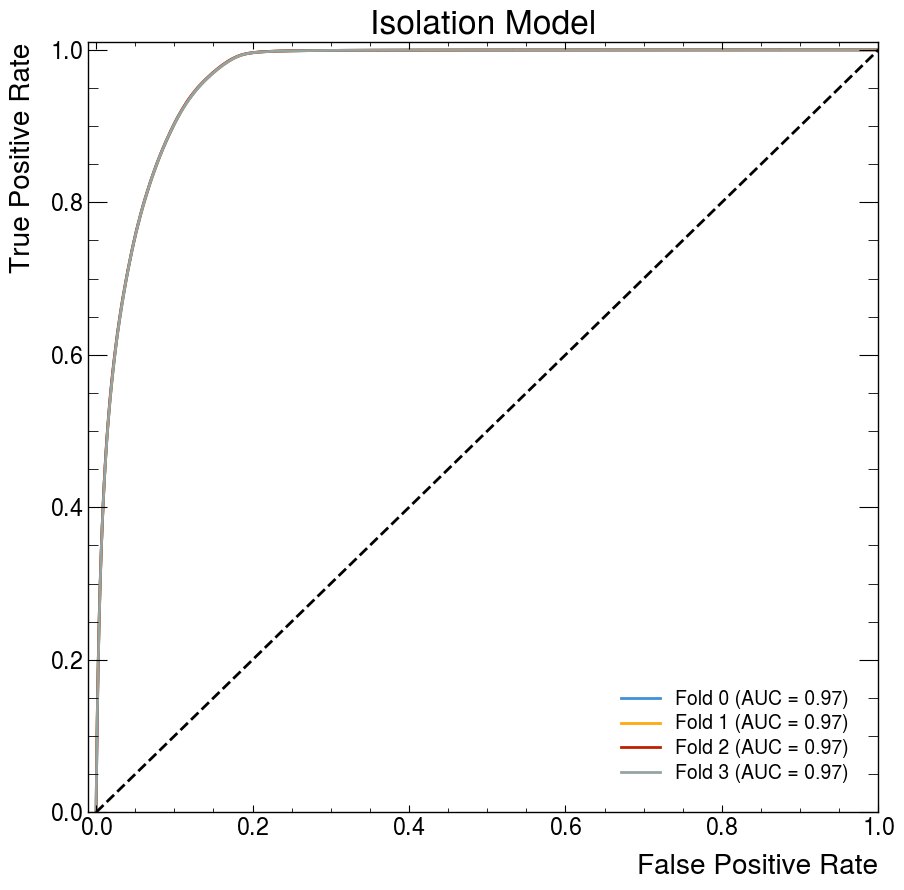

In [7]:
# plt.rcdefaults()
# hep.style.use([hep.style.ATLAS])


fig, ax = plt.subplots(figsize=(10, 10))
for i in range(4):
    with open(f'iso_tuner_{i}.pkl', 'rb') as f:
        tuner = pickle.load(f)
    X_test = Data[Data['EventInfo.eventNumber'] % 4 == i][iso_param_list]
    y_test = target[Data['EventInfo.eventNumber'] % 4 == i]
    y_pred = tuner.predict_proba(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_pred)
    roc_auc = auc(fpr, tpr)

    ax.plot(fpr, tpr, label=f'Fold {i} (AUC = {roc_auc:.2f})')
      
ax.plot([0, 1], [0, 1], 'k--')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_xlim([-0.01, 1.])
ax.set_ylim([0.0, 1.01])
ax.set_title('Isolation Model')
ax.legend()

In [8]:
print(target.sum()/len(target))

0.5


In [9]:
# small parameter list

print(iso_param_list[-4:])

['m_lx_topoetcone20', 'm_lx_topoetcone20ptCorrection', 'm_lx_topoetcone40', 'm_lx_neflowisol20']


In [10]:
small_param_list = iso_param_list[-4:]

for i in range(4):
    if os.path.exists(f'small_param_iso_tuner_{i}.pkl'):
        continue
    print('Training model', i)
    X_train = Data[Data['EventInfo.eventNumber'] % 4 != i][small_param_list]
    y_train = target[Data['EventInfo.eventNumber'] % 4 != i]

    X_test = Data[Data['EventInfo.eventNumber'] % 4 == i][small_param_list]
    y_test = target[Data['EventInfo.eventNumber'] % 4 == i]

    tuner = RapidGBMTuner(metric='auc', trials=50, refit=True, verbosity=1, visualization=True, seed=414243)
    tuner.fit(X_train, y_train)
    tuner.fit_optimized(X_train.to_numpy(), y_train.to_numpy())
    with open(f'small_param_iso_tuner_{i}.pkl', 'wb') as f:
            pickle.dump(tuner, f)

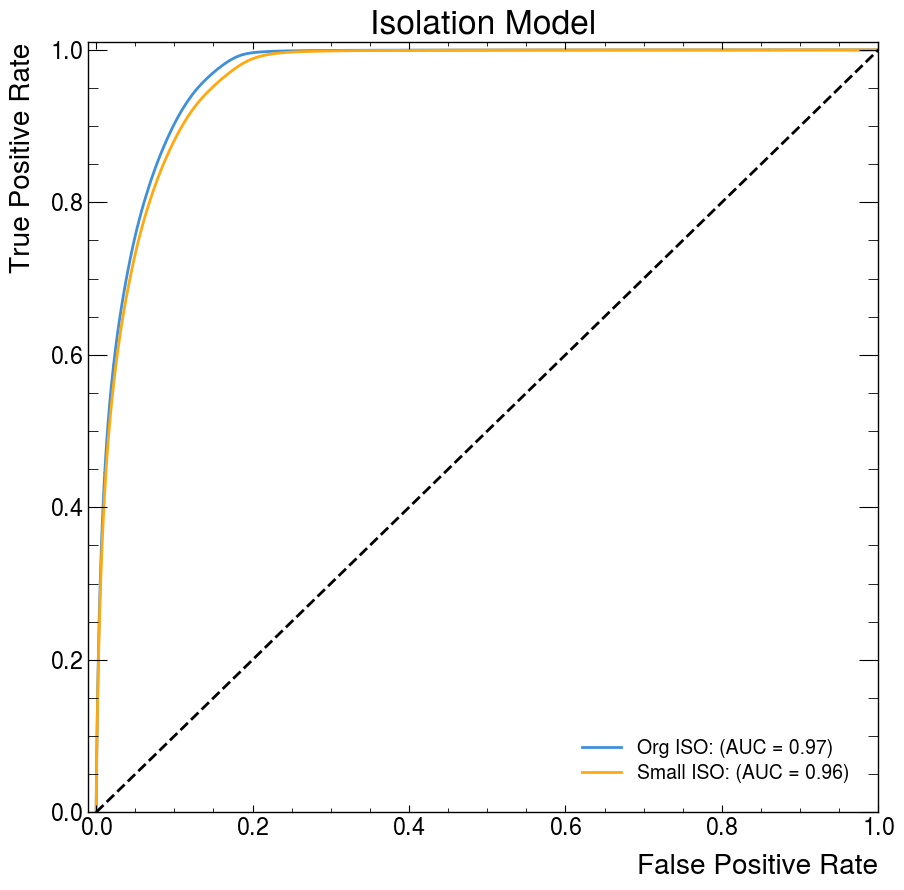

In [11]:
# plt.rcdefaults()
# hep.style.use([hep.style.ATLAS])

y_pred = np.zeros(len(target))
y_pred_small = np.zeros(len(target))

for i in range(4):
    X_test = Data[Data['EventInfo.eventNumber'] % 4 == i]

    with open(f'iso_tuner_{i}.pkl', 'rb') as f:
        tuner = pickle.load(f)
    
    y_pred[Data['EventInfo.eventNumber'] % 4 == i] = tuner.predict_proba(X_test[iso_param_list])

    with open(f'small_param_iso_tuner_{i}.pkl', 'rb') as f:
        tuner = pickle.load(f)
    
    y_pred_small[Data['EventInfo.eventNumber'] % 4 == i] = tuner.predict_proba(X_test[small_param_list])


fig, ax = plt.subplots(figsize=(10, 10))
fpr, tpr, _ = roc_curve(target, y_pred)
roc_auc = auc(fpr, tpr)

ax.plot(fpr, tpr, label=f'Org ISO: (AUC = {roc_auc:.2f})')

fpr, tpr, _ = roc_curve(target, y_pred_small)
roc_auc = auc(fpr, tpr)

ax.plot(fpr, tpr, label=f'Small ISO: (AUC = {roc_auc:.2f})')

ax.plot([0, 1], [0, 1], 'k--')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_xlim([-0.01, 1.])
ax.set_ylim([0.0, 1.01])
ax.set_title('Isolation Model')
ax.legend()

In [12]:
def unpair_df(data):
    """
    Unpairs columns in the DataFrame that start with 'l1' or 'l2' by renaming them to 'l'
    and concatenating the resulting DataFrames vertically.

    Parameters:
    data (pd.DataFrame): The original DataFrame containing columns to be unpaired.

    Returns:
    pd.DataFrame: A new DataFrame with columns starting with 'l1' and 'l2' renamed to 'l',
                  and the DataFrame length doubled by concatenating the modified DataFrames.
    """
    l1_columns = [col for col in data.columns if 'l1' in col]
    l2_columns = [col for col in data.columns if 'l2' in col]
    other_columns = [col for col in data.columns if not ('l1' in col or 'l2' in col)]

    # Create a copy of the DataFrame with 'l1' and 'l2' columns renamed to 'l'
    data_l1 = data[other_columns + l1_columns].copy()
    data_l2 = data[other_columns + l2_columns].copy()

    data_l1.rename(columns={col: col.replace('l1', 'm_lx', 1) for col in l1_columns}, inplace=True)
    data_l2.rename(columns={col: col.replace('l2', 'm_lx', 1) for col in l2_columns}, inplace=True)

    # Concatenate the DataFrames vertically
    new_data = pd.concat([data_l1, data_l2], ignore_index=True)
    return new_data


true_data_22 = pd.read_parquet('/groups/hep/kinch/data/Data/data22_13p6TeV.periodAllYear.physics_Main.PhysCont.DAOD_PHYS.grp22_v01_p6029/hist-sample_reduced.parquet')
print(f'shape data 22: {true_data_22.shape}')
true_data_23 = pd.read_parquet('/groups/hep/kinch/data/Data/data23_13p6TeV.periodAllYear.physics_Main.PhysCont.DAOD_PHYS.grp23_v01_p6029/hist-sample_reduced.parquet')
print(f'shape data 23: {true_data_23.shape}')
MC_data = pd.read_parquet('/groups/hep/kinch/data/preprocessed_data/files_from_grid/Data_BalZ_ttbar_zee.parquet')
print(f'shape MC data: {MC_data.shape}')

true_data = pd.concat([true_data_22, true_data_23])


true_data = unpair_df(true_data)

print('unpaired the data')

iso_score = np.zeros((len(true_data),4))
logit_scores = np.zeros((len(true_data),4))

for i in range(4):
    with open(f'small_param_iso_tuner_{i}.pkl', 'rb') as f:
        tuner = pickle.load(f)
    iso_score[:,i] = tuner.predict_proba(true_data[small_param_list])
    logit_scores[:,i] = np.log(iso_score[:,i]/(1-iso_score[:,i]))

shape data 22: (32936, 39)
shape data 23: (45757, 39)
shape MC data: (8792502, 40)
unpaired the data


In [15]:
# logit_scores = np.log(y_pred/(1-y_pred))
logit_scores_small = np.log(y_pred_small/(1-y_pred_small))
iso_score_data = iso_score.mean(axis=1)
logit_scores_data = logit_scores.mean(axis=1)

Text(1, 0, 'Logit Score')

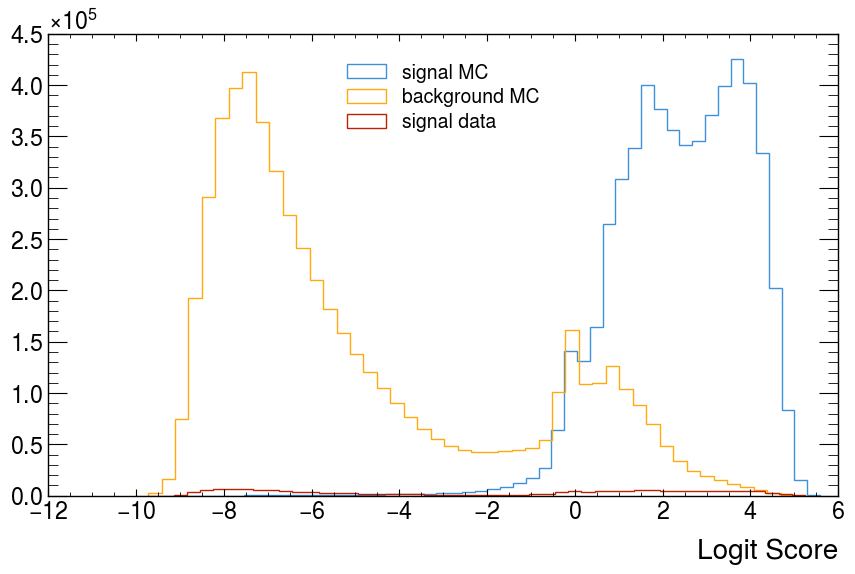

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))
bins_signal, edges_signal, _ = ax.hist(logit_scores_small[target==1], bins=50, histtype='step', label='signal MC')
bins_bck, edges_bck, _ = ax.hist(logit_scores_small[target==0], bins=50, histtype='step', label='background MC')
bins_data, edges_data, _ = ax.hist(logit_scores_data, bins=50, histtype='step', label='signal data')

ax.legend()
ax.set_xlabel('Logit Score')

<ValueView A1=0.010455656104226968 A2=0.015643296045149916 scale=0.9997017223243626 shift=-0.0015342990711145438>


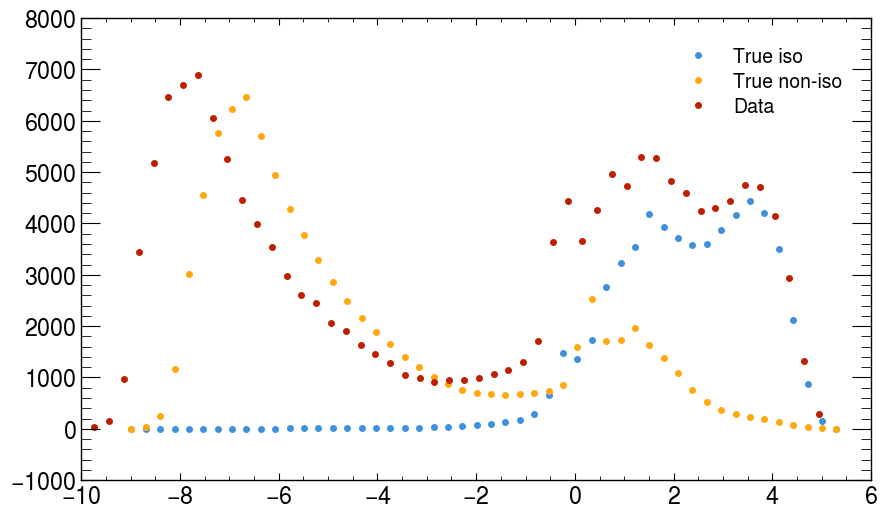

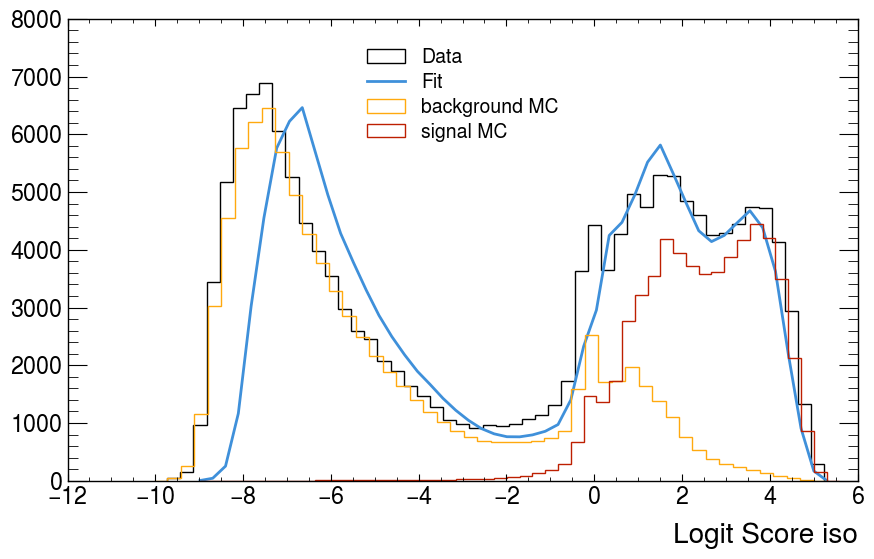

In [43]:
# fit data and MC

from iminuit import Minuit

error_sig = np.sqrt(bins_signal)
error_bck = np.sqrt(bins_bck)
error_data = np.sqrt(bins_data)

def MAE(A1, A2, scale, shift):
    x = scale * (edges_signal + shift)
    y = A1*bins_signal + A2*bins_bck

    dx = ( x[1:] - x[:-1] / 2 ) - ( edges_signal[1:] - edges_signal[:-1] / 2 )
    dy = y - bins_data

    distances = np.sqrt(dx**2 + dy**2)
    error_combined = np.sqrt(error_sig**2 + error_bck**2 + error_data**2)
    weighted_avg = np.average(distances, weights=1/error_combined)
    return weighted_avg

m = Minuit(MAE, A1=0.075, A2=0.042, scale=1, shift=0)
# m.limits['A1'] = (0.05, 1)
# m.limits['A2'] = (0, 1)
# m.limits['scale'] = (0.5, 2)
# m.limits['shift'] = (-1, 1)



m.migrad()

print(m.values)


fig, ax = plt.subplots(figsize=(10, 6))
ax.plot((edges_signal[:-1]-m.values[3])*m.values[2], bins_signal*m.values[0], '.', label='True iso')
ax.plot((edges_signal[:-1]-m.values[3])*m.values[2], bins_bck*m.values[1], '.', label='True non-iso')
ax.plot(edges_data[:-1], bins_data, '.', label='Data')

ax.legend()

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(logit_scores_data, color='black', bins=50, histtype='step', label='Data')
ax.plot((edges_signal[:-1]-m.values[3])*m.values[2], bins_signal*m.values[0]+bins_bck*m.values[1], label='Fit')
ax.hist(logit_scores_small[target==0], bins=50,weights=m.values[1]*np.ones_like(logit_scores_small[target==0]) , histtype='step', label='background MC')
ax.hist(logit_scores_small[target==1], bins=50,weights=m.values[0]*np.ones_like(logit_scores_small[target==1]) , histtype='step', label='signal MC')
ax.set_xlabel('Logit Score iso')
ax.legend()